Dataset ESS cargado correctamente.

Forma final del dataset ESS: (35726, 9)
Columnas finales: Index(['ENCUENTROS_SOCIALES', 'SALUD_PERCIBIDA', 'SALUD_LIMITA', 'BILINGUAL',
       'GENERO', 'ANOS_EDUCACION', 'INGRESOS_HOGAR', 'BUENA_SALUD',
       'INGRESOS_HOGAR_NUM'],
      dtype='object')

Primeras 5 filas del dataset ESS:
   ENCUENTROS_SOCIALES SALUD_PERCIBIDA        SALUD_LIMITA  BILINGUAL  GENERO  \
0                    5            Fair                  No          1       0   
1                    0            Good  Yes to some extent          0       1   
2                    5       Very good                  No          0       1   
3                    6            Fair                  No          1       1   
5                    6       Very good                  No          0       1   

   ANOS_EDUCACION  INGRESOS_HOGAR  BUENA_SALUD  INGRESOS_HOGAR_NUM  
0              12  S - 6th decile            0                   9  
1              14  J - 1st decile            1  

C:\Users\Lennie\AppData\Local\Temp\ipykernel_348\1274474952.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_ess['GENERO'] = df_ess['GENERO'].replace({'Male': 0, 'Female': 1}).astype(int)


Precisión (Accuracy) del Random Forest: 0.678

Entrenando el modelo XGBoost Classifier...
Precisión (Accuracy) de XGBoost: 0.687

Realizando análisis de interpretabilidad con SHAP...

Gráfico de resumen (Summary Plot):


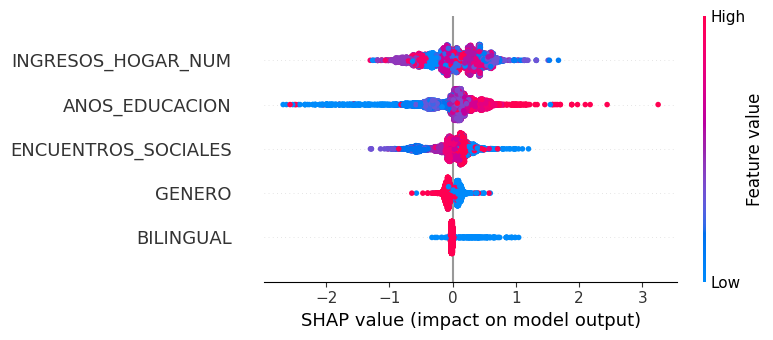


Gráfico de dependencia (Dependence Plot):


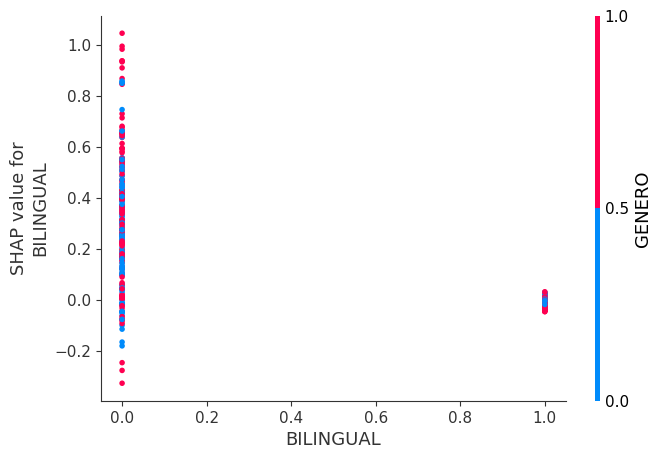

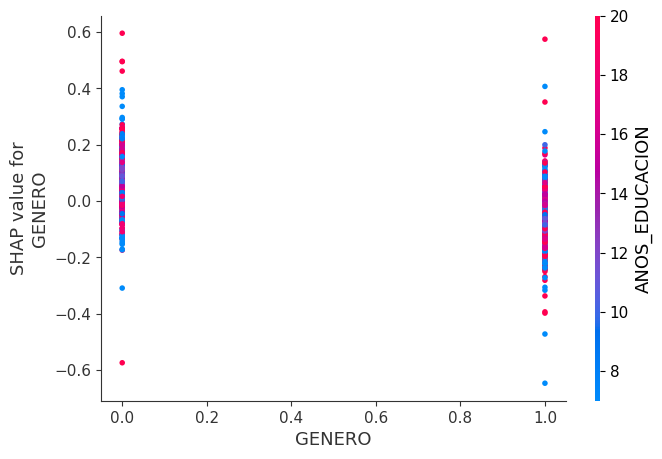

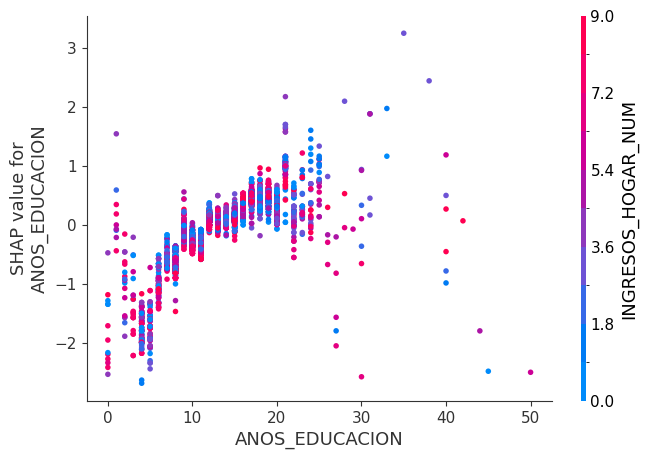

In [ ]:
import pandas as pd
import pyreadstat
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import xgboost as xgb
import shap

# Definimos una opción para evitar futuros warnings en pandas
pd.set_option('future.no_silent_downcasting', True)

# --- 1. CARGA Y LIMPIEZA DE DATOS ---
ruta_archivo = r"C:\Users\Lennie\Documents\GEMA\Master Data science\TFM\BilingualMind\2. datasets\data\ESS11.sav"

cols_necesarias = [
    "gndr", "eduyrs", "hinctnta", "health", "hlthhmp", "sclmeet", "lnghom2"
]

try:
    df_ess, metadata = pyreadstat.read_sav(ruta_archivo, usecols=cols_necesarias, apply_value_formats=True)
    print("Dataset ESS cargado correctamente.")
except FileNotFoundError:
    print("Error: Archivo no encontrado. Asegúrate de que la ruta y el nombre del archivo son correctos.")
    exit()

# Creo un diccionario para renombrar columnas y estandarizar nombres
column_map = {
    'lnghom2': 'BILINGUAL',
    'gndr': 'GENERO',
    'health': 'SALUD_PERCIBIDA',
    'hlthhmp': 'SALUD_LIMITA',
    'sclmeet': 'ENCUENTROS_SOCIALES',
    'hinctnta': 'INGRESOS_HOGAR',
    'eduyrs': 'ANOS_EDUCACION'
}
df_ess = df_ess.rename(columns={k: v for k, v in column_map.items() if k in df_ess.columns})

# Convierto la columna de bilingüismo a 1 (bilingüe) y 0 (no bilingüe)
if 'BILINGUAL' in df_ess.columns:
    df_ess['BILINGUAL'] = (df_ess['BILINGUAL'] != 'English').astype(int)

# Aseguro que la columna de género tenga valores 0 y 1.
if 'GENERO' in df_ess.columns:
    df_ess['GENERO'] = df_ess['GENERO'].replace({'Male': 0, 'Female': 1}).astype(int)

# Transformo la columna de salud en una variable binaria
if 'SALUD_PERCIBIDA' in df_ess.columns:
    df_ess['BUENA_SALUD'] = df_ess['SALUD_PERCIBIDA'].isin(['Very good', 'Good']).astype(int)

# Convierto la columna de ingresos en valores numéricos
if 'INGRESOS_HOGAR' in df_ess.columns:
    le = LabelEncoder()
    df_ess['INGRESOS_HOGAR_NUM'] = le.fit_transform(df_ess['INGRESOS_HOGAR'])

# Elimino filas con valores nulos antes de las transformaciones de tipo
df_ess = df_ess.dropna()

# Convierto variables a numéricas de tipo entero después de eliminar los nulos
if 'ANOS_EDUCACION' in df_ess.columns:
    df_ess['ANOS_EDUCACION'] = df_ess['ANOS_EDUCACION'].astype(int)
if 'ENCUENTROS_SOCIALES' in df_ess.columns:
    le = LabelEncoder()
    df_ess['ENCUENTROS_SOCIALES'] = le.fit_transform(df_ess['ENCUENTROS_SOCIALES'])
    df_ess['ENCUENTROS_SOCIALES'] = df_ess['ENCUENTROS_SOCIALES'].astype(int)


print(f"\nForma final del dataset ESS: {df_ess.shape}")
print("Columnas finales:", df_ess.columns)
print("\nPrimeras 5 filas del dataset ESS:")
print(df_ess.head())

# --- 2. ENTRENAMIENTO DE MODELOS DE CLASIFICACIÓN ---

# Defino la variable a predecir (y)
y = df_ess['BUENA_SALUD']

# Defino las variables predictoras (X)
X = df_ess[['BILINGUAL', 'GENERO', 'ANOS_EDUCACION', 'INGRESOS_HOGAR_NUM', 'ENCUENTROS_SOCIALES']].copy()

# Divido el dataset en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entreno y evaluo el modelo Random Forest Classifier
print("\nEntrenando el modelo Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Precisión (Accuracy) del Random Forest: {rf_accuracy:.3f}")

# Entreno y evaluo el modelo XGBoost Classifier
print("\nEntrenando el modelo XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"Precisión (Accuracy) de XGBoost: {xgb_accuracy:.3f}")

# --- 3. INTERPRETABILIDAD CON SHAP ---

print("\nRealizando análisis de interpretabilidad con SHAP...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Genero un gráfico de resumen (Summary Plot) para mostrar la importancia de las variables
print("\nGráfico de resumen (Summary Plot):")
shap.summary_plot(shap_values, X_test)
plt.show()

# Genero un gráfico de dependencia (Dependence Plot) para las variables más importantes
print("\nGráfico de dependencia (Dependence Plot):")
for col in X_test.columns[:3]:  # Top 3 variables
    shap.dependence_plot(col, shap_values, X_test)
    plt.show()